In [1]:
# -*- coding: utf-8 -*-
"""
试卷 D - 图像增强技术综合应用
要求：亮度/对比度调整、锐化、边缘增强、综合滤镜
测试图像需为 'image_test.jpg'
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt

cv2：OpenCV库，用于图像处理和计算机视觉操作

numpy：数值计算库，提供多维数组支持

matplotlib.pyplot：绘图库，用于显示图像结果

In [2]:
# 设置中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

中文字体设置：配置Matplotlib使用黑体显示中文，并正确显示负号

In [3]:
# 读取测试图片（请确保存在 image_test.jpg）
image = cv2.imread('pexels-photo-415829.jpeg')
if image is None:
    print("错误：未找到 image_test.jpg，请将测试图片放在当前目录下")
    exit()
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # 转为 RGB 以便 matplotlib 显示

cv2.imread()：读取图像文件，默认以BGR格式加载

错误处理：检查图像是否成功加载，失败则提示用户并退出程序

颜色空间转换：OpenCV使用BGR格式，Matplotlib使用RGB格式，需要进行转换

In [4]:
# ==================== 1. 亮度与对比度调整 ====================
def adjust_brightness_contrast(img, brightness=30, contrast=50):
    """
    brightness: 0-100, 默认30
    contrast: 0-100, 默认50
    """
    brightness = brightness / 100.0      # 归一化到 [0,1]
    contrast = contrast / 100.0
    alpha = 1 + contrast                # 对比度系数
    beta = brightness * 255             # 亮度增量
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

函数功能：通过线性变换调整图像的亮度和对比度

参数范围：亮度和对比度参数范围均为0-100，默认值分别为30和50

归一化处理：将输入参数除以100，转换为0-1范围的比例值

计算公式：alpha = 1 + contrast控制对比度，beta = brightness * 255控制亮度

cv2.convertScaleAbs()：执行像素值的线性变换并取绝对值

In [5]:
# 调用
brightness_val, contrast_val = 30, 50
adjusted = adjust_brightness_contrast(image, brightness_val, contrast_val)
adjusted_rgb = cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB)

参数设置：使用默认值亮度30、对比度50

函数调用：应用亮度对比度调整函数

颜色转换：将结果转换为RGB格式用于显示

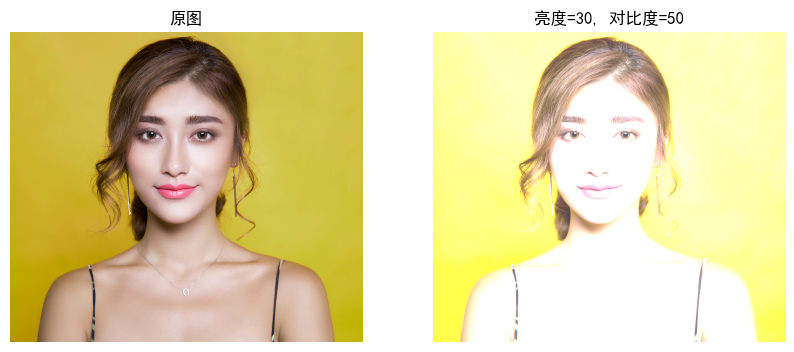

In [6]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('原图')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(adjusted_rgb)
plt.title(f'亮度={brightness_val}, 对比度={contrast_val}')
plt.axis('off')
plt.show()

可视化设置：创建10×5英寸的画布，左右并排显示原图和调整后图像

plt.subplot(1, 2, 1)：创建1行2列的子图，当前操作第1个

plt.axis('off')：隐藏坐标轴，使图像显示更清晰

In [7]:
# ==================== 2. 图像锐化处理 ====================
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
sharpened = cv2.filter2D(image, -1, kernel_sharpen)
sharpened_rgb = cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)

锐化核定义：3×3的拉普拉斯锐化核，中心权重为5，周围为-1

核的作用：增强图像边缘和细节，使图像看起来更清晰

cv2.filter2D()：对图像进行二维卷积操作，应用锐化核

深度参数-1：表示输出图像与输入图像具有相同的深度

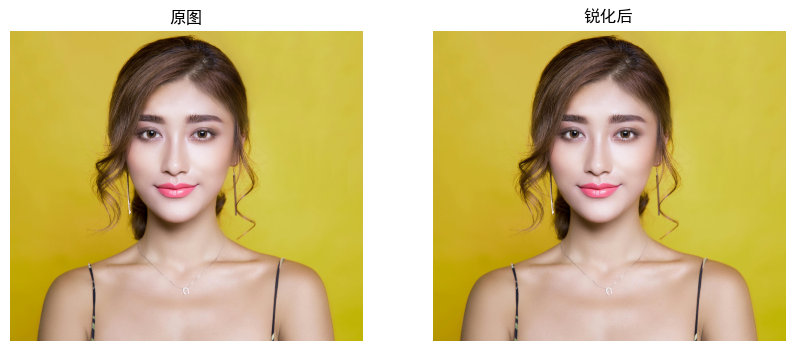

In [8]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('原图')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(sharpened_rgb)
plt.title('锐化后')
plt.axis('off')
plt.show()

In [9]:
# ==================== 3. 边缘增强效果（Laplacian） ====================
laplacian = cv2.Laplacian(image, cv2.CV_64F)
edge_enhanced = cv2.convertScaleAbs(laplacian)
edge_enhanced_rgb = cv2.cvtColor(edge_enhanced, cv2.COLOR_BGR2RGB)

cv2.Laplacian()：应用拉普拉斯算子进行边缘检测

cv2.CV_64F：指定输出图像的数据类型为64位浮点数

拉普拉斯算子：二阶微分算子，对图像中的快速变化区域（边缘）响应强烈

cv2.convertScaleAbs()：将浮点数结果转换为绝对值并缩放到0-255范围

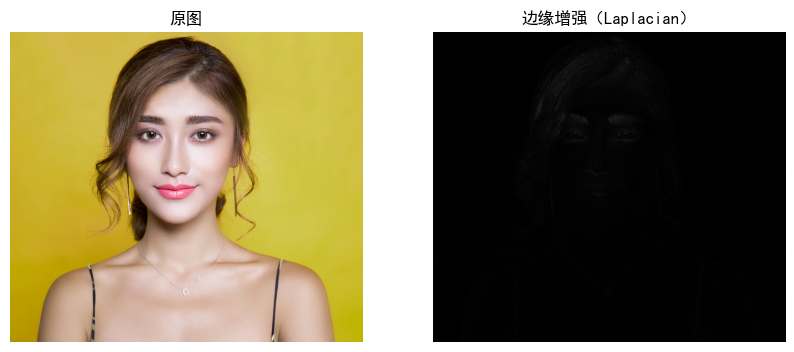

In [10]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('原图')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(edge_enhanced_rgb, cmap='gray')
plt.title('边缘增强（Laplacian）')
plt.axis('off')
plt.show()

In [11]:
# ==================== 4. 综合滤镜效果 ====================
def apply_filter(img):
    # 步骤1：亮度对比度调整
    img1 = adjust_brightness_contrast(img, brightness=20, contrast=40)
    # 步骤2：高斯模糊（去噪）
    img2 = cv2.GaussianBlur(img1, (5, 5), 0)
    # 步骤3：锐化
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    img3 = cv2.filter2D(img2, -1, kernel)
    # 步骤4：边缘增强（Laplacian）
    laplacian = cv2.Laplacian(img3, cv2.CV_64F)
    img4 = cv2.convertScaleAbs(laplacian)
    return img4

四步处理流程：亮度对比度调整 → 高斯模糊去噪 → 锐化处理 → 边缘增强

第一步：使用自定义函数调整亮度和对比度（亮度20，对比度40）

第二步：cv2.GaussianBlur()应用5×5高斯核进行平滑去噪

第三步：使用与前面相同的锐化核增强细节

第四步：拉普拉斯边缘检测，突出图像轮廓

这种组合处理可以产生艺术化或特殊效果的图像

In [12]:
filtered = apply_filter(image)
filtered_rgb = cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB)

应用综合滤镜函数处理原始图像

颜色空间转换：将BGR结果转换为RGB用于显示

可视化对比：左侧显示原图，右侧显示综合滤镜效果

cmap='gray'：指定使用灰度色彩映射显示边缘增强结果

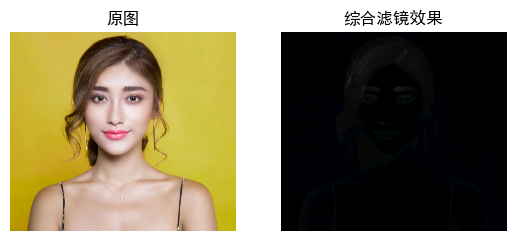

所有图像增强任务完成。


In [13]:
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('原图')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(filtered_rgb, cmap='gray')
plt.title('综合滤镜效果')
plt.axis('off')
plt.show()

print("所有图像增强任务完成。")